# Evaluación con Tuning — Consumo Metro Medellín

**Cambios respecto al notebook base:**
- Test = **últimos 4 meses del dataset** (auto-detectados)
- Validación cruzada tipo *walk-forward* sobre los `N_VAL_FOLDS` meses anteriores al test
- Búsqueda aleatoria de hiperparámetros (`N_ITER` iteraciones por modelo)
- Re-entrenamiento final con mejores params sobre **todo el pre-test**
- Tabla de comparación **defaults vs tuned**

```
[──── TRAIN EXPANDIBLE ────][── VAL FOLDS (CV tuning) ──][── TEST (4 meses) ──]
                             fold_1 fold_2 … fold_N        M-3  M-2  M-1  M
```


## 1. Imports

In [ ]:
import re, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

try:
    import lightgbm as lgb; HAS_LGB = True
    print(f"✓ LightGBM {lgb.__version__}")
except ImportError:
    HAS_LGB = False; print("✗ LightGBM no instalado")

try:
    import xgboost as xgb; HAS_XGB = True
    print(f"✓ XGBoost  {xgb.__version__}")
except ImportError:
    HAS_XGB = False; print("✗ XGBoost no instalado")

try:
    from tqdm.auto import tqdm; HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    class tqdm:  # fallback mínimo
        def __init__(self, iterable=None, **kw): self._it = iterable or []
        def __iter__(self): return iter(self._it)
        def set_postfix(self, **kw): pass

print("✓ Librerías base listas")


✓ LightGBM 4.6.0
✓ XGBoost  3.2.0
✓ Librerías base listas


## 2. Configuración global

In [ ]:
# ─── AJUSTA AQUÍ ─────────────────────────────────────────────────────────────
CSV_PATH     = 'features_mes_completo.csv'

N_VAL_FOLDS  = 6    # meses de CV anteriores al test
N_ITER       = 25   # iteraciones de random search por modelo  (~5-15 min total)
SEED         = 42
# ─────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(SEED)

COLORS = {
    'LightGBM'    : '#1976D2',
    'XGBoost'     : '#E64A19',
    'RandomForest': '#388E3C',
}

MODELS = []
if HAS_LGB: MODELS.append('LightGBM')
if HAS_XGB: MODELS.append('XGBoost')
MODELS.append('RandomForest')

print(f"Modelos activos : {MODELS}")
print(f"Val folds (CV)  : {N_VAL_FOLDS}")
print(f"Iteraciones RS  : {N_ITER}  → {len(MODELS)*N_ITER*N_VAL_FOLDS} fits totales")


Modelos activos : ['LightGBM', 'XGBoost', 'RandomForest']
Val folds (CV)  : 6
Iteraciones RS  : 25  → 450 fits totales


## 3. Carga del dataset

In [ ]:
df = pd.read_csv(CSV_PATH, index_col='Fecha', parse_dates=True)
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

print(f"Shape           : {df.shape}")
print(f"Rango de fechas : {df.index.min().date()} → {df.index.max().date()}")
nulos = df.isnull().sum()
nc = nulos[nulos > 0]
print(f"Columnas con nulos: {len(nc)}" + (f"\n{nc}" if len(nc) else " — ninguno"))
print(f"\nConsumo — media: {df['Consumo'].mean():,.0f}  "
      f"std: {df['Consumo'].std():,.0f}  "
      f"min: {df['Consumo'].min():,.0f}  max: {df['Consumo'].max():,.0f}")


Shape           : (2852, 90)
Rango de fechas : 2018-03-12 → 2025-12-31
Columnas con nulos: 0 — ninguno

Consumo — media: 69,212  std: 13,228  min: 19,741  max: 88,671


## 4. Feature sets

In [ ]:
all_cols = df.columns.tolist()
_pat_lag = re.compile(r'^lag_(\d+)$')

CALENDAR_ORDINAL = [c for c in [
    'dia_semana','mes','año','semana_año','es_fin_semana','es_festivo',
    'dia_antes_festivo','dia_despues_festivo','semana_navidad',
    'covid_cuarentena','es_mantenimiento'] if c in all_cols]

def get_lag_cols(cols):
    lags = [(int(_pat_lag.match(c).group(1)),c) for c in cols if _pat_lag.match(c)]
    return [c for _,c in sorted(lags)]

LAG_COLS  = get_lag_cols(all_cols)
ROLL_COLS = sorted([c for c in all_cols
                    if any(c.startswith(p) for p in
                           ['media_roll','std_roll','mediana_roll'])])

FEATURES_TREE = CALENDAR_ORDINAL + LAG_COLS + ROLL_COLS

print(f"Calendar : {len(CALENDAR_ORDINAL)}  |  "
      f"Lags : {len(LAG_COLS)}  |  "
      f"Rolling : {len(ROLL_COLS)}  |  "
      f"TOTAL : {len(FEATURES_TREE)}")
missing = [f for f in FEATURES_TREE if f not in all_cols]
print("✓ Todas las features en el CSV." if not missing
      else f"⚠ Faltantes: {missing}")


Calendar : 11  |  Lags : 62  |  Rolling : 12  |  TOTAL : 85
✓ Todas las features en el CSV.


## 5. Definición dinámica de splits

Los meses de **test** se auto-detectan como los últimos 4 meses con datos completos.  
Los meses de **validación** son los `N_VAL_FOLDS` meses inmediatamente anteriores al test.  
El **train** es todo lo que queda antes de cada fold (expanding window).


  Dataset completo : 2018-03-12 → 2025-12-31
  Pre-test (train+val) : 2018-03-12 → 2025-08-31  (2730 días)
  Val folds (6 meses) : 2025-03 → 2025-08
  Test  (4 meses)  : 2025-09 → 2025-12


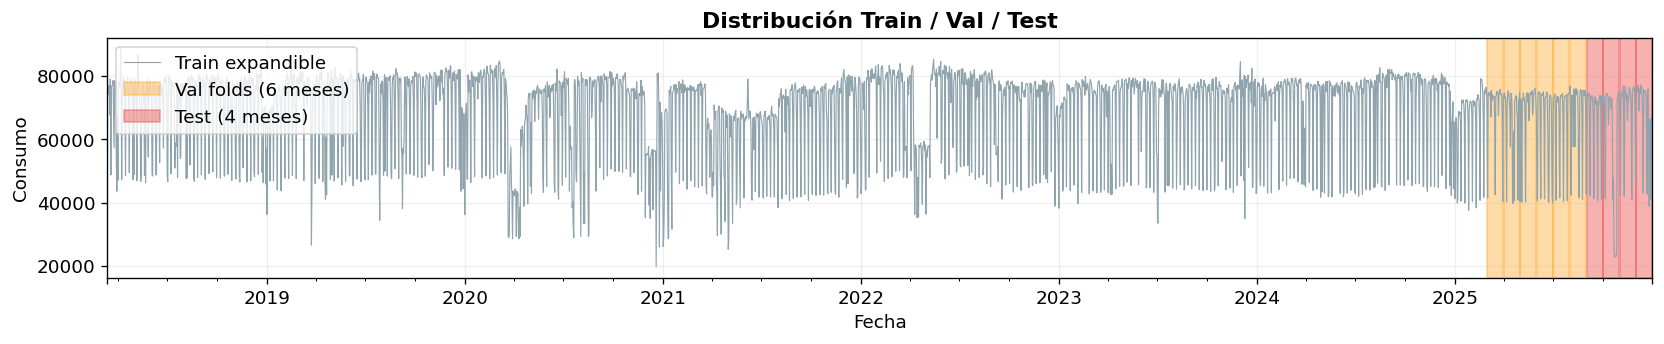

In [ ]:
# ── Detectar últimos 4 meses completos del dataset ───────────────────────────
last_period   = df.index.max().to_period('M')
# Verificar que el último mes tiene datos en todo el mes o es el mes en curso
# Usar el penúltimo mes como referencia segura si el último está incompleto
def month_row_count(period):
    start = pd.Timestamp(str(period) + '-01')
    end   = start + pd.offsets.MonthEnd(1)
    return len(df[(df.index >= start) & (df.index <= end)])

# Buscar los últimos 4 meses con al menos 20 días de datos
complete_months = []
p = last_period
while len(complete_months) < 4:
    if month_row_count(p) >= 20:
        complete_months.insert(0, p)
    p -= 1

TEST_MONTHS = [str(m) for m in complete_months]
test_start  = pd.Timestamp(f'{TEST_MONTHS[0]}-01')

# ── Val folds: N_VAL_FOLDS meses antes del test ───────────────────────────────
p = (pd.Timestamp(f'{TEST_MONTHS[0]}-01') - pd.offsets.MonthBegin(1)).to_period('M')
VAL_MONTHS = []
while len(VAL_MONTHS) < N_VAL_FOLDS:
    if month_row_count(p) >= 20:
        VAL_MONTHS.insert(0, str(p))
    p -= 1

val_start  = pd.Timestamp(f'{VAL_MONTHS[0]}-01')

# ── Resumen ────────────────────────────────────────────────────────────────────
pre_test     = df[df.index < test_start]    # todo lo que no es test
full_train   = df[df.index < val_start]     # solo para referencia

print("=" * 55)
print(f"  Dataset completo : {df.index.min().date()} → {df.index.max().date()}")
print(f"  Pre-test (train+val) : {pre_test.index.min().date()} "
      f"→ {pre_test.index.max().date()}  ({len(pre_test)} días)")
print(f"  Val folds ({N_VAL_FOLDS} meses) : {VAL_MONTHS[0]} → {VAL_MONTHS[-1]}")
print(f"  Test  (4 meses)  : {TEST_MONTHS[0]} → {TEST_MONTHS[-1]}")
print("=" * 55)

# Visualización del split
fig, ax = plt.subplots(figsize=(14, 3))
df['Consumo'].plot(ax=ax, lw=0.7, color='#90A4AE', label='Train expandible')

for mes in VAL_MONTHS:
    s = pd.Timestamp(f'{mes}-01')
    e = s + pd.offsets.MonthEnd(1)
    ax.axvspan(s, e, color='#FFA726', alpha=0.4)
ax.axvspan(0, 0, color='#FFA726', alpha=0.4, label=f'Val folds ({N_VAL_FOLDS} meses)')

for mes in TEST_MONTHS:
    s = pd.Timestamp(f'{mes}-01')
    e = s + pd.offsets.MonthEnd(1)
    ax.axvspan(s, e, color='#EF5350', alpha=0.45)
ax.axvspan(0, 0, color='#EF5350', alpha=0.45, label='Test (4 meses)')

ax.set_title('Distribución Train / Val / Test', fontweight='bold')
ax.set_ylabel('Consumo'); ax.legend(loc='upper left'); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('split_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Funciones auxiliares

In [ ]:
def mask_invalid_lags(X_test: pd.DataFrame) -> pd.DataFrame:
    """Anula lag_k donde k < día del mes (no disponibles en producción)."""
    X_m = X_test.copy()
    lag_info = {c: int(_pat_lag.match(c).group(1))
                for c in X_test.columns if _pat_lag.match(c)}
    for date in X_m.index:
        N = date.day
        for col, k in lag_info.items():
            if k < N:
                X_m.loc[date, col] = np.nan
    return X_m


def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100
    r2   = r2_score(y_true, y_pred)
    return {'MAE':round(mae,2),'RMSE':round(rmse,2),
            'MAPE (%)':round(mape,4),'R²':round(r2,4)}


def fit_predict(model_name, params, X_train, y_train, X_test_masked,
                early_stop=False):
    """
    Entrena el modelo con los params dados y retorna (preds, model).
    early_stop=True solo para el entrenamiento final (no durante CV).
    """
    if model_name == 'LightGBM':
        m = lgb.LGBMRegressor(**params, random_state=SEED, verbose=-1)
        if early_stop:
            m.set_params(n_estimators=3000)
            m.fit(X_train, y_train,
                  eval_set=[(X_train[-200:], y_train[-200:])],
                  callbacks=[lgb.early_stopping(60, verbose=False),
                              lgb.log_evaluation(-1)])
        else:
            m.fit(X_train, y_train)
        return m.predict(X_test_masked), m

    elif model_name == 'XGBoost':
        m = xgb.XGBRegressor(**params, tree_method='hist',
                              random_state=SEED, verbosity=0)
        if early_stop:
            m.set_params(n_estimators=3000)
            m.fit(X_train, y_train,
                  eval_set=[(X_train[-200:], y_train[-200:])],
                  verbose=False)
        else:
            m.fit(X_train, y_train)
        return m.predict(X_test_masked), m

    elif model_name == 'RandomForest':
        imp = SimpleImputer(strategy='mean')
        Xtr = imp.fit_transform(X_train)
        Xte = imp.transform(X_test_masked)
        m = RandomForestRegressor(**params, n_jobs=-1, random_state=SEED)
        m.fit(Xtr, y_train)
        m._imputer = imp
        return m.predict(Xte), m


def cv_score_model(model_name, params, val_months):
    """
    Walk-forward CV: entrena en todo lo anterior a cada val_month y predice ese mes.
    Retorna MAPE medio (métrica de tuning).
    """
    mapes = []
    for mes in val_months:
        cutoff = pd.Timestamp(f'{mes}-01')
        end    = cutoff + pd.offsets.MonthEnd(1)
        tr  = df[df.index < cutoff]
        val = df[(df.index >= cutoff) & (df.index <= end)]
        if len(tr) < 365 or len(val) == 0:
            continue
        Xtr, ytr = tr[FEATURES_TREE], tr['Consumo']
        Xv , yv  = val[FEATURES_TREE], val['Consumo']
        Xv_m = mask_invalid_lags(Xv)
        try:
            preds, _ = fit_predict(model_name, params, Xtr, ytr, Xv_m,
                                   early_stop=False)
            mapes.append(compute_metrics(yv.values, preds)['MAPE (%)'])
        except Exception:
            mapes.append(999)
    return float(np.mean(mapes)) if mapes else 999.0


print("✓ Funciones definidas.")


✓ Funciones definidas.


## 7. Espacios de hiperparámetros

Búsqueda aleatoria (*random search*) sobre los espacios definidos.  
El criterio de selección es el **MAPE medio** sobre los folds de validación.


In [ ]:
def sample_params(model_name):
    """Samplea un conjunto de hiperparámetros aleatorio para el modelo."""
    if model_name == 'LightGBM':
        return dict(
            n_estimators     = int(rng.choice([400,600,800,1000,1200,1500])),
            learning_rate    = float(rng.choice([0.02,0.03,0.04,0.05,0.07,0.10])),
            num_leaves       = int(rng.choice([31,47,63,95,127])),
            min_child_samples= int(rng.choice([10,15,20,25,30])),
            subsample        = float(rng.choice([0.70,0.75,0.80,0.85,0.90])),
            colsample_bytree = float(rng.choice([0.60,0.70,0.75,0.80,0.90])),
            reg_alpha        = float(rng.choice([0,0.05,0.10,0.30,0.50,1.0])),
            reg_lambda       = float(rng.choice([0.1,0.3,0.5,1.0,2.0,5.0])),
        )
    elif model_name == 'XGBoost':
        return dict(
            n_estimators     = int(rng.choice([400,600,800,1000,1200])),
            learning_rate    = float(rng.choice([0.02,0.03,0.04,0.05,0.07,0.10])),
            max_depth        = int(rng.choice([4,5,6,7,8])),
            subsample        = float(rng.choice([0.70,0.75,0.80,0.85,0.90])),
            colsample_bytree = float(rng.choice([0.60,0.70,0.75,0.80,0.90])),
            reg_alpha        = float(rng.choice([0,0.05,0.10,0.30,0.50,1.0])),
            reg_lambda       = float(rng.choice([0.5,1.0,2.0,5.0,10.0])),
            min_child_weight = int(rng.choice([1,3,5,10,20])),
        )
    elif model_name == 'RandomForest':
        max_depth = None if rng.random() < 0.3 else int(rng.choice([10,15,20,25,30]))
        return dict(
            n_estimators  = int(rng.choice([300,500,700,800])),
            max_depth     = max_depth,
            min_samples_leaf = int(rng.choice([2,3,4,5,6,8])),
            max_features  = str(rng.choice(['sqrt','log2'])),
            max_samples   = float(rng.choice([0.7,0.8,0.9,1.0])),
        )

# Parámetros por defecto (baseline del notebook anterior)
DEFAULT_PARAMS = {
    'LightGBM': dict(n_estimators=1200, learning_rate=0.04, num_leaves=63,
                     min_child_samples=15, subsample=0.85, colsample_bytree=0.75,
                     reg_alpha=0.1, reg_lambda=0.5),
    'XGBoost' : dict(n_estimators=1200, learning_rate=0.04, max_depth=6,
                     subsample=0.85, colsample_bytree=0.75,
                     reg_alpha=0.1, reg_lambda=1.0, min_child_weight=1),
    'RandomForest': dict(n_estimators=600, max_depth=None,
                         min_samples_leaf=4, max_features='sqrt', max_samples=1.0),
}

print("✓ Espacios de hiperparámetros definidos.")
print(f"  {N_ITER} iteraciones × {N_VAL_FOLDS} folds × {len(MODELS)} modelos "
      f"= {N_ITER*N_VAL_FOLDS*len(MODELS)} entrenamientos de CV")


✓ Espacios de hiperparámetros definidos.
  25 iteraciones × 6 folds × 3 modelos = 450 entrenamientos de CV


## 8. Búsqueda aleatoria de hiperparámetros

Cada iteración samplea parámetros al azar y evalúa con walk-forward CV.  
Al finalizar se elige el conjunto con menor MAPE medio.


In [ ]:
tuning_results = {}   # tuning_results[model] = DataFrame con resultados
best_params    = {}   # best_params[model]    = dict de params ganadores
t0_global = time.time()

for model_name in MODELS:
    print(f"\n{'─'*55}")
    print(f"  Tuning {model_name}  ({N_ITER} iteraciones, {N_VAL_FOLDS} folds cada una)")
    print(f"{'─'*55}")

    rows = []
    t0 = time.time()

    for i in tqdm(range(N_ITER), desc=model_name):
        params = sample_params(model_name)
        score  = cv_score_model(model_name, params, VAL_MONTHS)
        rows.append({'iter': i+1, 'cv_mape': score, **params})
        if (i+1) % 5 == 0 or (i+1) == N_ITER:
            best_so_far = min(r['cv_mape'] for r in rows)
            elapsed = time.time() - t0
            print(f"  iter {i+1:>3}/{N_ITER}  |  "
                  f"MAPE actual={score:.3f}%  |  "
                  f"mejor={best_so_far:.3f}%  |  "
                  f"tiempo={elapsed:.0f}s")

    df_res = pd.DataFrame(rows).sort_values('cv_mape').reset_index(drop=True)
    tuning_results[model_name] = df_res

    best_row   = df_res.iloc[0]
    param_cols = [c for c in df_res.columns if c not in ('iter','cv_mape')]
    best_p     = best_row[param_cols].to_dict()
    # n_estimators debe ser int, otros floats/int según tipo
    for k,v in best_p.items():
        if isinstance(v, float) and v == int(v) and k in (
                'n_estimators','num_leaves','min_child_samples',
                'max_depth','min_samples_leaf','min_child_weight'):
            best_p[k] = int(v)
        if k == 'max_depth' and pd.isna(v):
            best_p[k] = None

    best_params[model_name] = best_p
    print(f"\n  ✓ Mejor MAPE CV = {best_row['cv_mape']:.3f}%")
    print(f"  Params: {best_p}")

print(f"\n{'='*55}")
print(f"  Tuning completado en {(time.time()-t0_global)/60:.1f} min")
print(f"{'='*55}")



───────────────────────────────────────────────────────
  Tuning LightGBM  (25 iteraciones, 6 folds cada una)
───────────────────────────────────────────────────────


LightGBM:   0%|          | 0/25 [00:00<?, ?it/s]

  iter   5/25  |  MAPE actual=10.170%  |  mejor=9.163%  |  tiempo=247s
  iter  10/25  |  MAPE actual=10.483%  |  mejor=9.163%  |  tiempo=596s
  iter  15/25  |  MAPE actual=11.437%  |  mejor=8.343%  |  tiempo=874s
  iter  20/25  |  MAPE actual=9.601%  |  mejor=8.343%  |  tiempo=1153s
  iter  25/25  |  MAPE actual=11.749%  |  mejor=8.343%  |  tiempo=1486s

  ✓ Mejor MAPE CV = 8.343%
  Params: {'n_estimators': 1200, 'learning_rate': 0.07, 'num_leaves': 63, 'min_child_samples': 30, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 1.0, 'reg_lambda': 0.3}

───────────────────────────────────────────────────────
  Tuning XGBoost  (25 iteraciones, 6 folds cada una)
───────────────────────────────────────────────────────


XGBoost:   0%|          | 0/25 [00:00<?, ?it/s]

  iter   5/25  |  MAPE actual=10.560%  |  mejor=9.648%  |  tiempo=155s
  iter  10/25  |  MAPE actual=9.770%  |  mejor=9.648%  |  tiempo=345s
  iter  15/25  |  MAPE actual=10.839%  |  mejor=9.437%  |  tiempo=561s
  iter  20/25  |  MAPE actual=9.525%  |  mejor=9.437%  |  tiempo=946s
  iter  25/25  |  MAPE actual=9.453%  |  mejor=9.437%  |  tiempo=1115s

  ✓ Mejor MAPE CV = 9.437%
  Params: {'n_estimators': 800, 'learning_rate': 0.02, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.7, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'min_child_weight': 10}

───────────────────────────────────────────────────────
  Tuning RandomForest  (25 iteraciones, 6 folds cada una)
───────────────────────────────────────────────────────


RandomForest:   0%|          | 0/25 [00:00<?, ?it/s]

  iter   5/25  |  MAPE actual=8.847%  |  mejor=7.914%  |  tiempo=173s
  iter  10/25  |  MAPE actual=8.083%  |  mejor=7.914%  |  tiempo=331s
  iter  15/25  |  MAPE actual=8.654%  |  mejor=7.914%  |  tiempo=513s
  iter  20/25  |  MAPE actual=9.136%  |  mejor=7.784%  |  tiempo=693s
  iter  25/25  |  MAPE actual=7.864%  |  mejor=7.784%  |  tiempo=892s


ValueError: cannot convert float NaN to integer

In [ ]:
for model_name in MODELS:
    df_res   = tuning_results[model_name]
    best_row = df_res.iloc[0]
    param_cols = [c for c in df_res.columns if c not in ('iter', 'cv_mape')]
    best_p = best_row[param_cols].to_dict()

    for k, v in best_p.items():
        if pd.isna(v):
            best_p[k] = None
        elif isinstance(v, float) and v == int(v) and k in (
                'n_estimators', 'num_leaves', 'min_child_samples',
                'max_depth', 'min_samples_leaf', 'min_child_weight'):
            best_p[k] = int(v)

    best_params[model_name] = best_p
    print(f"{model_name}: {best_p}")

LightGBM: {'n_estimators': 1200, 'learning_rate': 0.07, 'num_leaves': 63, 'min_child_samples': 30, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 1.0, 'reg_lambda': 0.3}
XGBoost: {'n_estimators': 800, 'learning_rate': 0.02, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.7, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'min_child_weight': 10}
RandomForest: {'n_estimators': 800, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_samples': 0.9}


## 9. Resultados del tuning

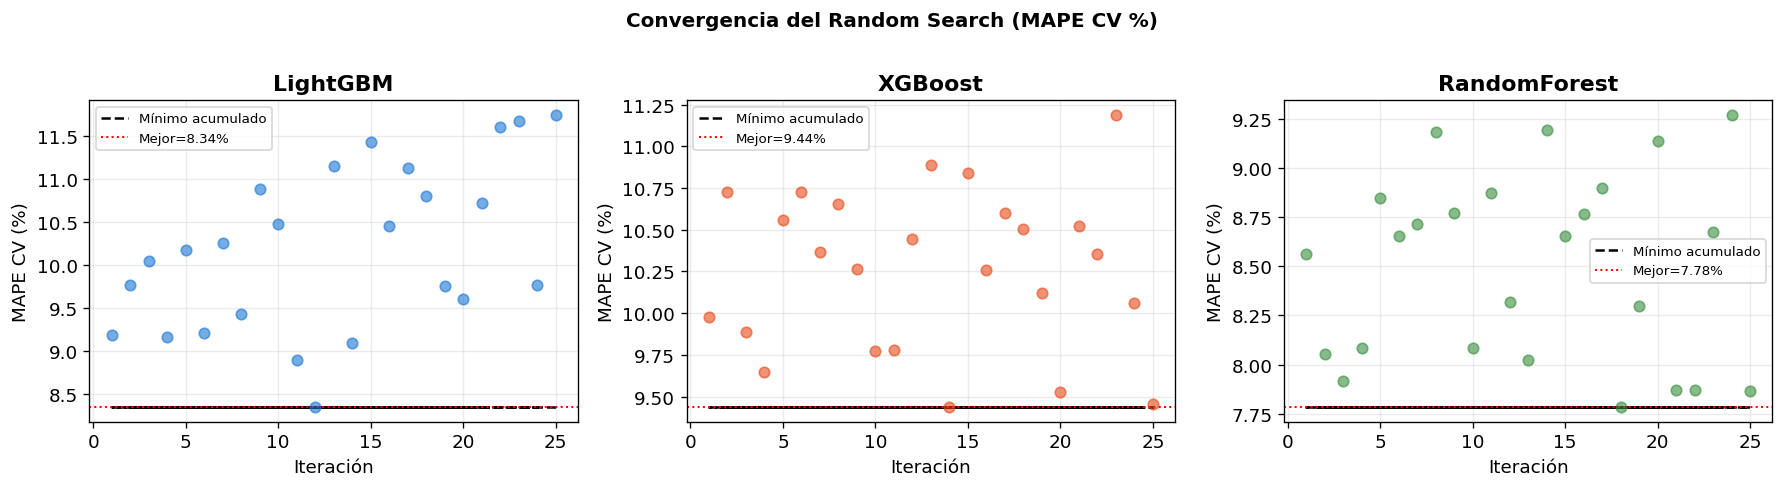


── Mejores params encontrados ──

LightGBM:
  n_estimators          : 1200
  learning_rate         : 0.07
  num_leaves            : 63
  min_child_samples     : 30
  subsample             : 0.9
  colsample_bytree      : 0.7
  reg_alpha             : 1.0
  reg_lambda            : 0.3

XGBoost:
  n_estimators          : 800
  learning_rate         : 0.02
  max_depth             : 5
  subsample             : 0.8
  colsample_bytree      : 0.7
  reg_alpha             : 0.0
  reg_lambda            : 5.0
  min_child_weight      : 10

RandomForest:
  n_estimators          : 800
  max_depth             : None
  min_samples_leaf      : 2
  max_features          : sqrt
  max_samples           : 0.9


In [ ]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 4), sharey=False)
if len(MODELS) == 1: axes = [axes]

for ax, model_name in zip(axes, MODELS):
    df_res = tuning_results[model_name]
    ax.scatter(df_res['iter'], df_res['cv_mape'],
               color=COLORS[model_name], alpha=0.6, s=40, zorder=3)
    # Running minimum
    ax.plot(df_res['iter'], df_res['cv_mape'].cummin(),
            'k--', lw=1.5, label='Mínimo acumulado')
    best = df_res['cv_mape'].min()
    ax.axhline(best, color='red', lw=1.2, ls=':', label=f'Mejor={best:.2f}%')
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_xlabel('Iteración')
    ax.set_ylabel('MAPE CV (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle('Convergencia del Random Search (MAPE CV %)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tuning_convergencia.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Mejores params encontrados ──")
for model_name in MODELS:
    print(f"\n{model_name}:")
    for k,v in best_params[model_name].items():
        print(f"  {k:22s}: {v}")


## 10. Evaluación final en test

Se re-entrena cada modelo **dos veces** sobre todo el pre-test:
1. Con **parámetros por defecto** (baseline del notebook anterior)
2. Con los **mejores parámetros** del random search

Ambas versiones se evalúan sobre los mismos 4 meses de test.


In [ ]:
def eval_all_months(params_dict, label=''):
    """
    Para cada modelo en params_dict y cada mes de test,
    entrena en todo el pre-test y evalúa.
    Retorna dict results[mes][modelo] = {preds, real, dates, metrics, model}
    """
    res = {}
    for mes_test in TEST_MONTHS:
        cutoff = pd.Timestamp(f'{mes_test}-01')
        end    = cutoff + pd.offsets.MonthEnd(1)
        train  = df[df.index < cutoff]
        test   = df[(df.index >= cutoff) & (df.index <= end)]

        Xtr, ytr = train[FEATURES_TREE], train['Consumo']
        Xte, yte = test[FEATURES_TREE],  test['Consumo']
        Xte_m = mask_invalid_lags(Xte)

        res[mes_test] = {}
        for model_name, params in params_dict.items():
            preds, model = fit_predict(
                model_name, params, Xtr, ytr, Xte_m, early_stop=True)
            metrics = compute_metrics(yte.values, preds)
            res[mes_test][model_name] = {
                'preds': preds, 'real': yte.values,
                'dates': yte.index, 'metrics': metrics, 'model': model,
            }
    return res


print("Evaluando con parámetros por defecto…")
results_default = eval_all_months(
    {m: DEFAULT_PARAMS[m] for m in MODELS}, label='default')

print("Evaluando con parámetros tuneados…")
results_tuned   = eval_all_months(best_params, label='tuned')

print("\n✓ Evaluación completa.")


Evaluando con parámetros por defecto…
Evaluando con parámetros tuneados…

✓ Evaluación completa.


## 11. Predicción vs Real — parámetros tuneados

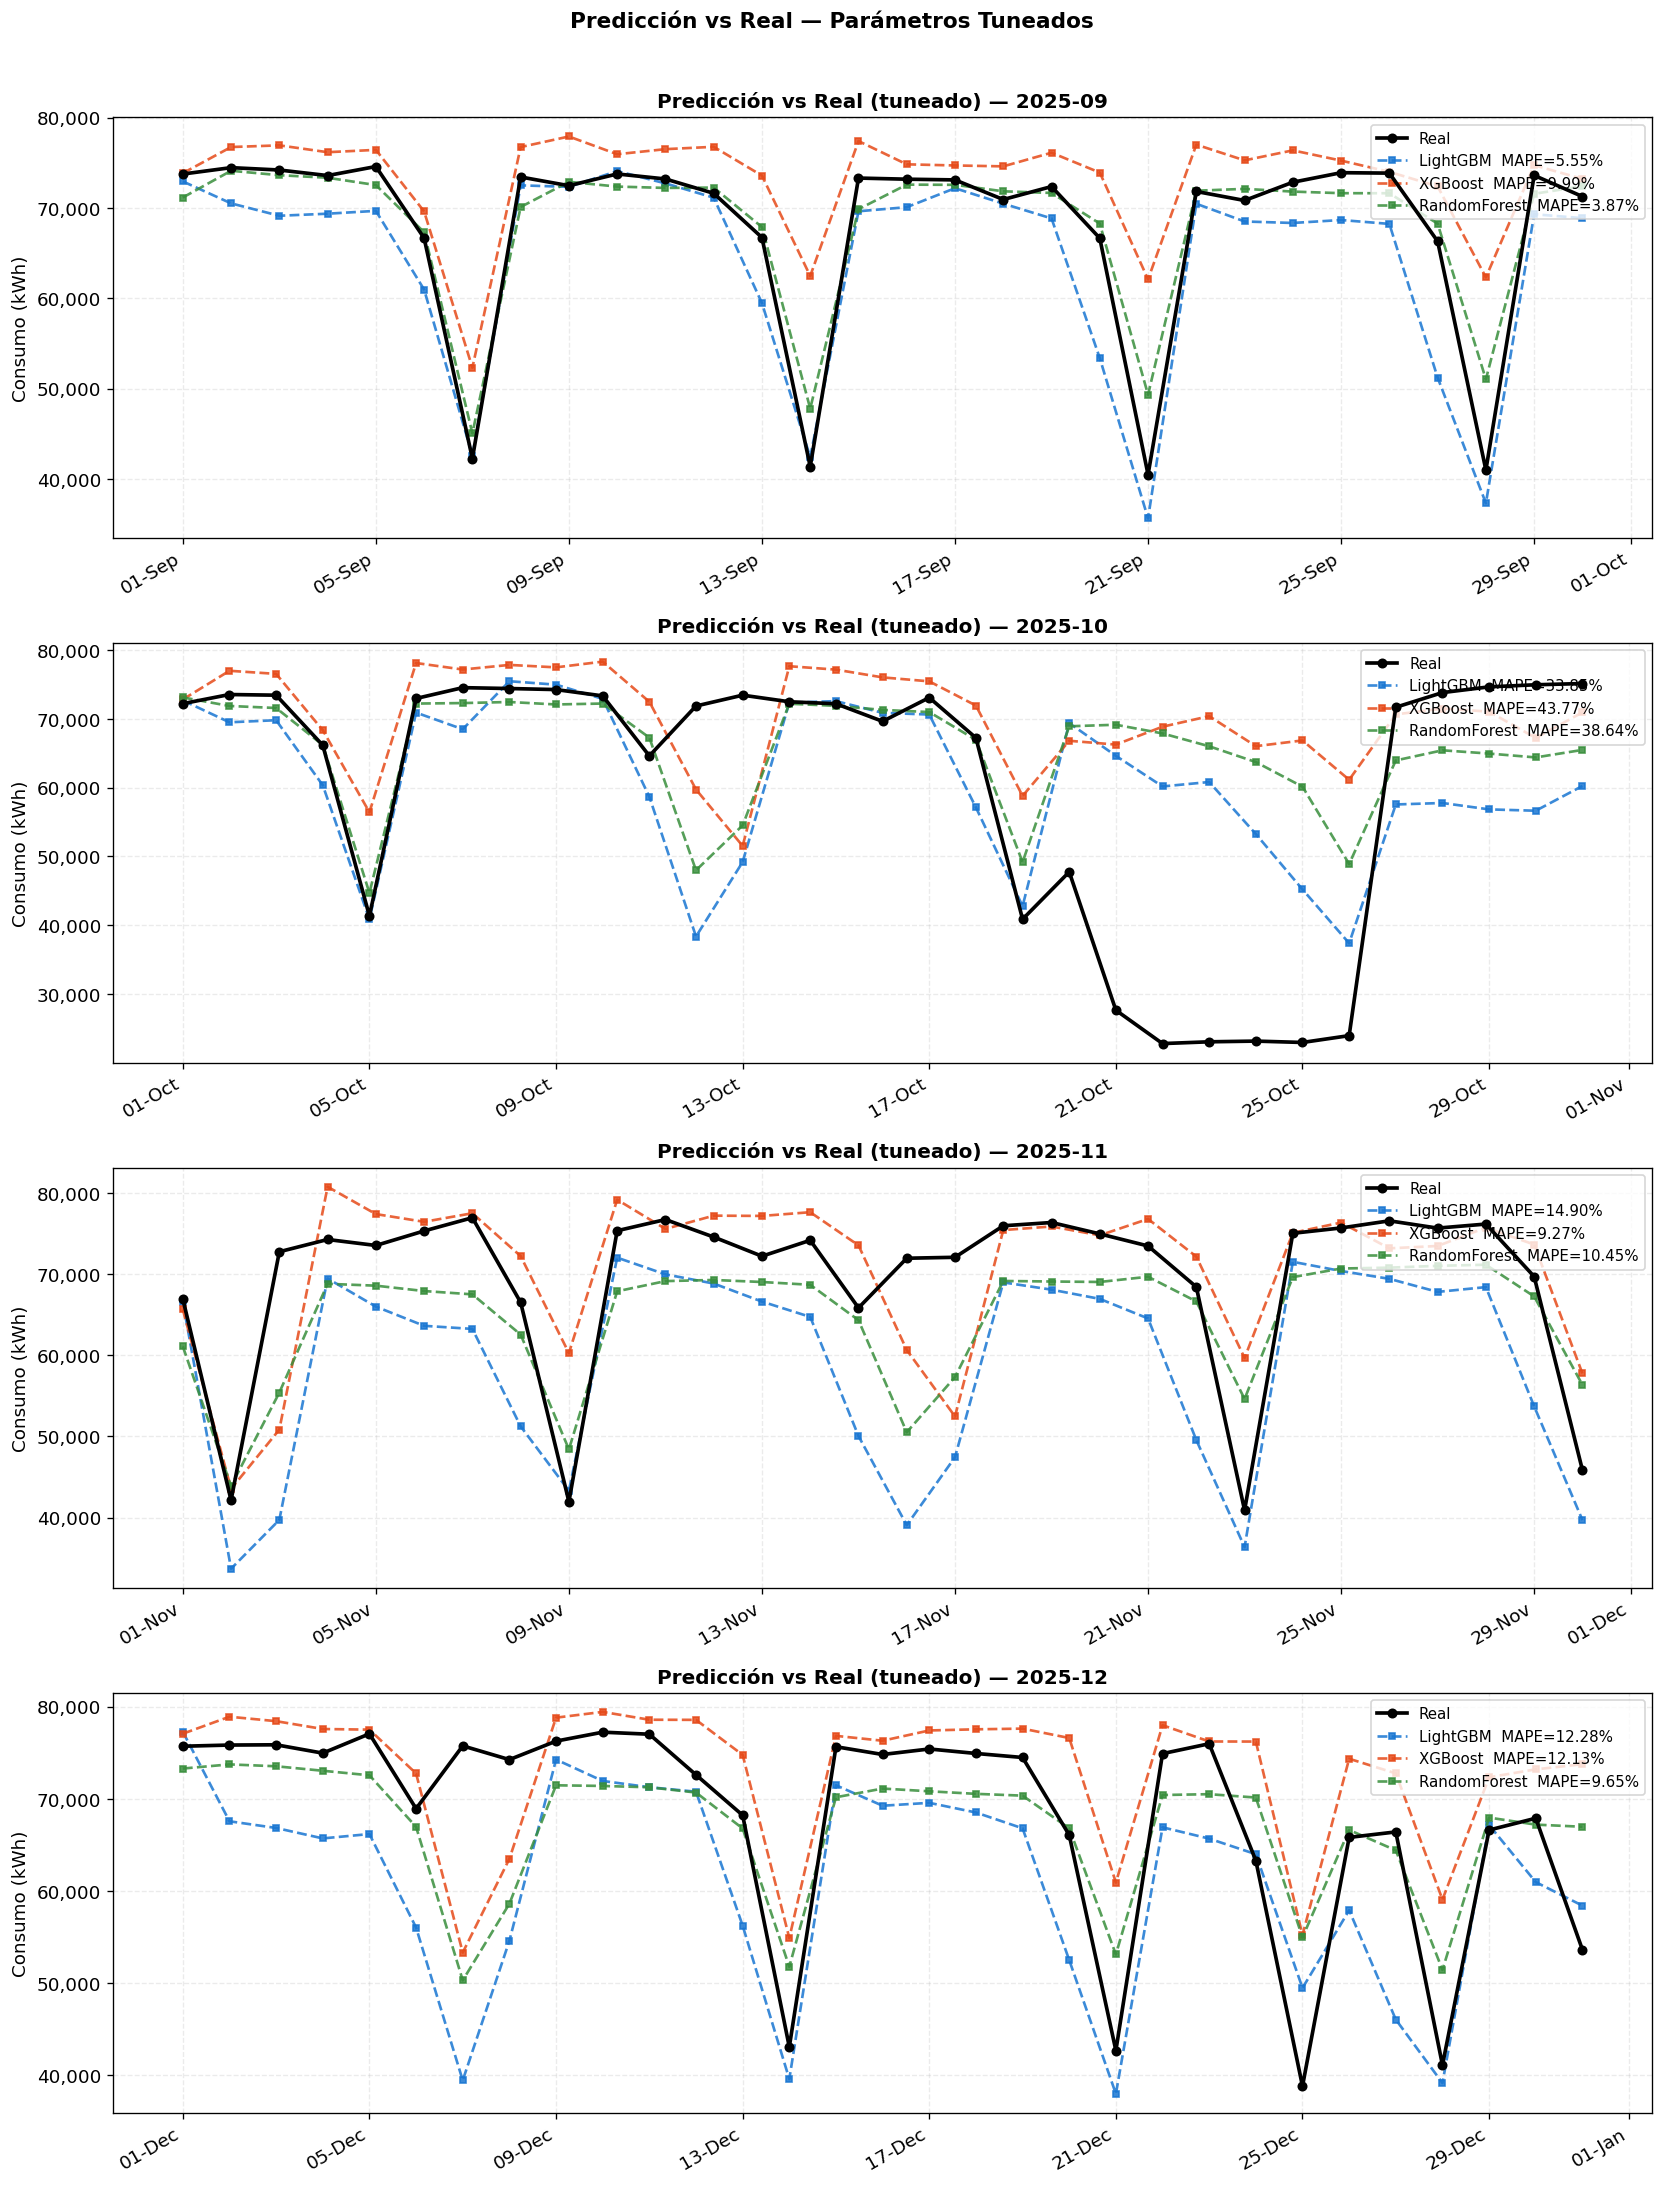

In [ ]:
n = len(TEST_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.5*n), sharex=False)
if n == 1: axes = [axes]

for ax, mes in zip(axes, TEST_MONTHS):
    dates = results_tuned[mes][MODELS[0]]['dates']
    real  = results_tuned[mes][MODELS[0]]['real']
    ax.plot(dates, real, 'k-o', lw=2.2, ms=5, label='Real', zorder=6)

    for model_name in MODELS:
        p    = results_tuned[mes][model_name]['preds']
        mape = results_tuned[mes][model_name]['metrics']['MAPE (%)']
        ax.plot(dates, p, '--s', ms=4, lw=1.6,
                color=COLORS[model_name], alpha=0.85,
                label=f"{model_name}  MAPE={mape:.2f}%")

    ax.set_title(f'Predicción vs Real (tuneado) — {mes}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Consumo (kWh)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25, ls='--')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Predicción vs Real — Parámetros Tuneados',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pred_vs_real_tuned.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Degradación del error con el horizonte — parámetros tuneados

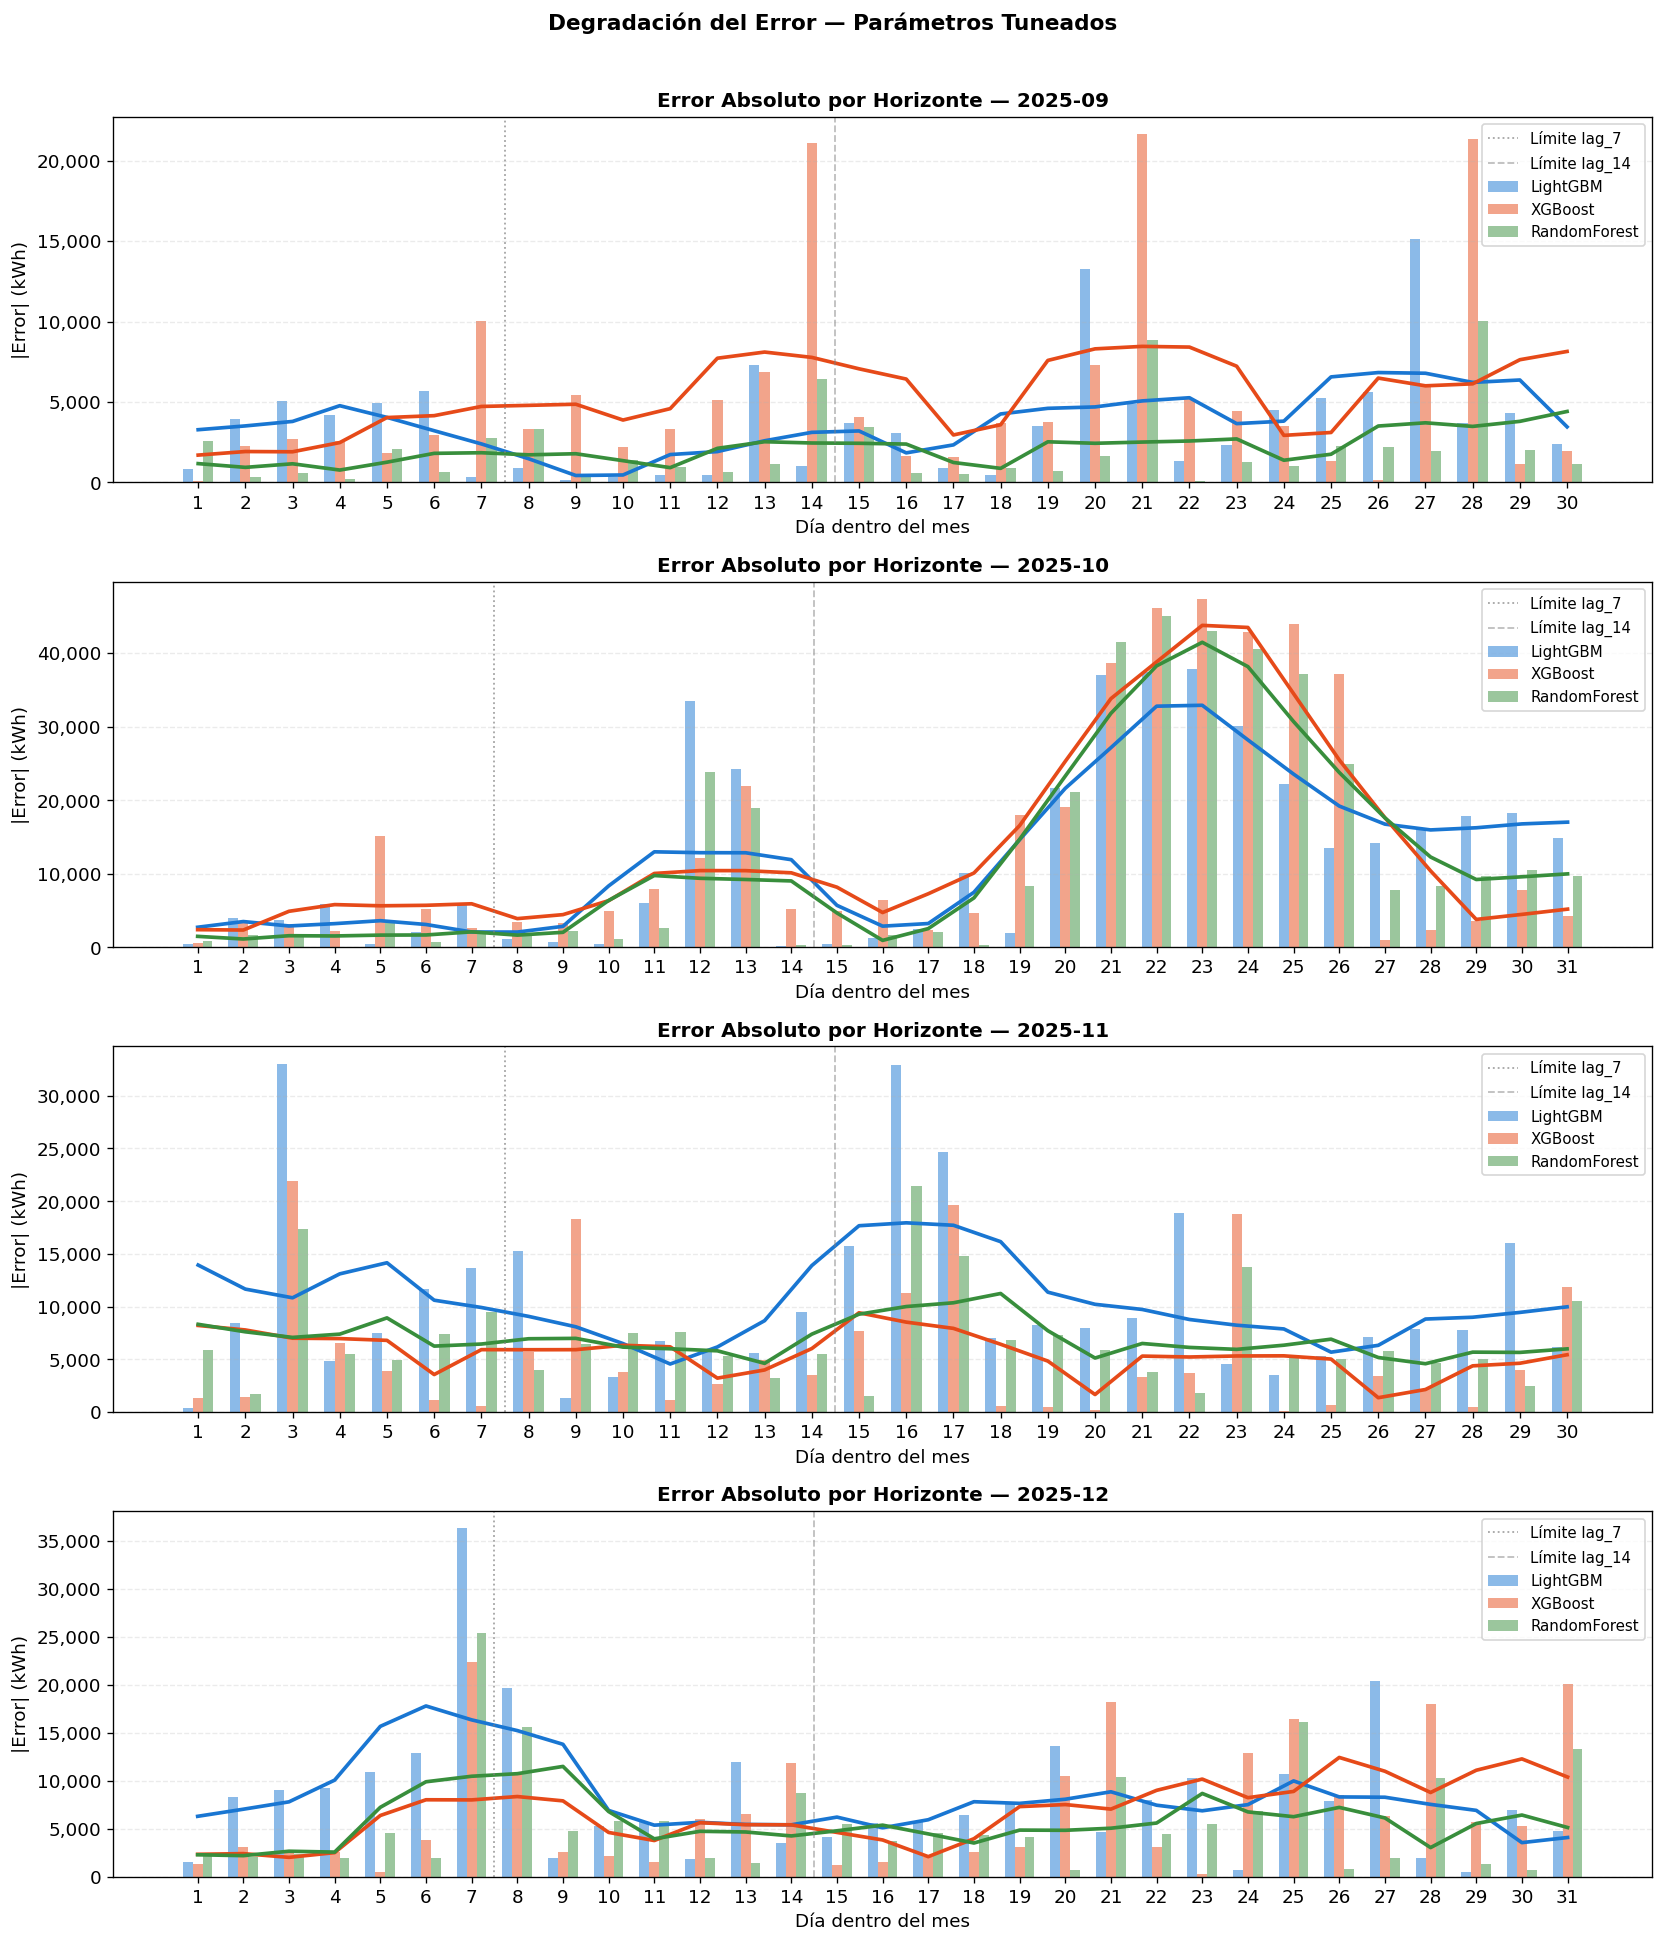

In [ ]:
n = len(TEST_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.0*n))
if n == 1: axes = [axes]

BAR_W   = 0.65 / max(len(MODELS),1)
offsets = {m:(i-(len(MODELS)-1)/2)*BAR_W for i,m in enumerate(MODELS)}

for ax, mes in zip(axes, TEST_MONTHS):
    real = results_tuned[mes][MODELS[0]]['real']
    dias = np.arange(1, len(real)+1)

    for model_name in MODELS:
        preds  = results_tuned[mes][model_name]['preds']
        errors = np.abs(real - preds)
        ax.bar(dias + offsets[model_name], errors,
               width=BAR_W, color=COLORS[model_name], alpha=0.5,
               label=model_name)
        trend = pd.Series(errors).rolling(5, center=True, min_periods=1).mean()
        ax.plot(dias, trend, '-', lw=2.2, color=COLORS[model_name])

    ax.axvline(7.5,  color='gray', lw=1.1, ls=':',  alpha=0.7, label='Límite lag_7')
    ax.axvline(14.5, color='gray', lw=1.1, ls='--', alpha=0.5, label='Límite lag_14')
    ax.set_title(f'Error Absoluto por Horizonte — {mes}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Día dentro del mes'); ax.set_ylabel('|Error| (kWh)')
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.25, ls='--')
    ax.set_xticks(dias)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Degradación del Error — Parámetros Tuneados',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('error_horizonte_tuned.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Tabla comparativa — Default vs Tuneado

Muestra el cambio en cada métrica para cada modelo y mes de test.  
`Δ MAPE` negativo = mejora.


In [ ]:
rows_def, rows_tun = [], []

for mes in TEST_MONTHS:
    for model_name in MODELS:
        for tag, res in [('Default', results_default),
                         ('Tuned',   results_tuned)]:
            m = res[mes][model_name]['metrics']
            (rows_def if tag == 'Default' else rows_tun).append({
                'Mes':mes, 'Modelo':model_name,
                'MAE':m['MAE'], 'RMSE':m['RMSE'],
                'MAPE (%)':m['MAPE (%)'], 'R²':m['R²'],
            })

df_def = pd.DataFrame(rows_def).set_index(['Mes','Modelo'])
df_tun = pd.DataFrame(rows_tun).set_index(['Mes','Modelo'])

# Delta
df_delta = df_tun - df_def
df_delta.columns = [f'Δ {c}' for c in df_delta.columns]

print("\n══ MÉTRICAS DEFAULT ════════════════════════════════════════")
print(df_def.to_string())

print("\n══ MÉTRICAS TUNEADAS ═══════════════════════════════════════")
print(df_tun.to_string())

print("\n══ DELTA (Tuned − Default; negativo = mejora en MAE/RMSE/MAPE) ═══")
print(df_delta.to_string())

# Promedio por modelo
print("\n── Promedio sobre meses de test ──────────────────────────────")
print("DEFAULT:")
print(df_def.groupby('Modelo').mean().round(2).to_string())
print("\nTUNED:")
print(df_tun.groupby('Modelo').mean().round(2).to_string())



══ MÉTRICAS DEFAULT ════════════════════════════════════════
                           MAE      RMSE  MAPE (%)      R²
Mes     Modelo                                            
2025-09 LightGBM       4941.73   5826.61    7.4594  0.7046
        XGBoost        4986.47   7932.90    9.6810  0.4524
        RandomForest   2265.72   3470.32    4.2510  0.8952
2025-10 LightGBM      13721.72  17975.40   34.2661  0.1772
        XGBoost       13829.68  21036.78   44.5077 -0.1269
        RandomForest  12221.81  19180.15   39.2268  0.0633
2025-11 LightGBM      12612.89  15384.79   18.0801 -1.0052
        XGBoost        6349.44  10946.49   11.4954 -0.0151
        RandomForest   6493.15   7883.93    9.8562  0.4734
2025-12 LightGBM       8564.77  11011.87   12.4111  0.0844
        XGBoost        5963.23   8540.51   10.6545  0.4492
        RandomForest   5860.81   8174.98    9.8149  0.4954

══ MÉTRICAS TUNEADAS ═══════════════════════════════════════
                           MAE      RMSE  MAPE (%)

## 14. Comparativa visual — Default vs Tuneado (MAPE %)

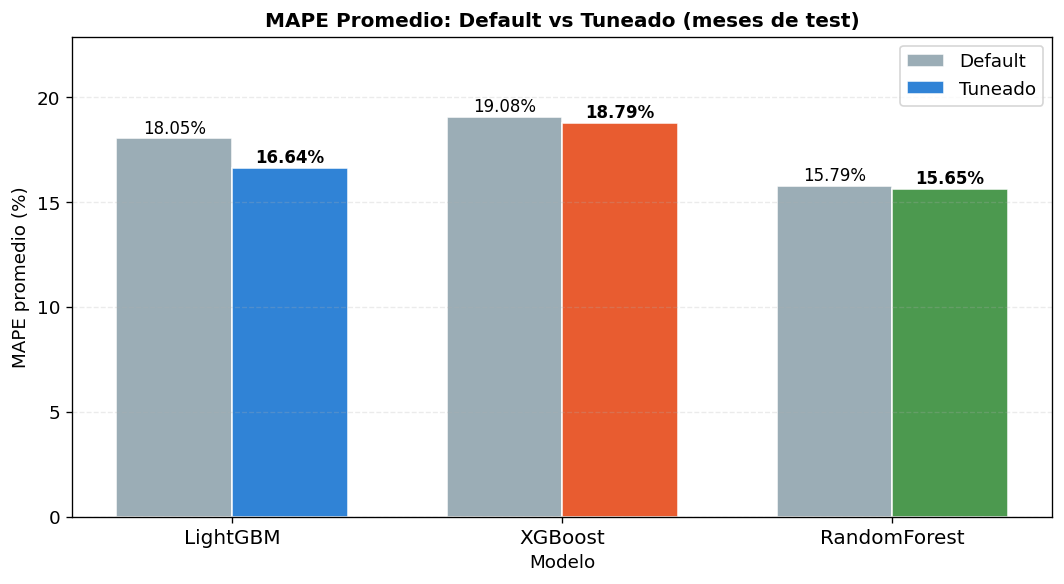

In [ ]:
avg_def = df_def.groupby('Modelo')['MAPE (%)'].mean()
avg_tun = df_tun.groupby('Modelo')['MAPE (%)'].mean()

x    = np.arange(len(MODELS))
w    = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, [avg_def[m] for m in MODELS], w,
            label='Default', color='#90A4AE', edgecolor='white', alpha=0.9)
b2 = ax.bar(x + w/2, [avg_tun[m] for m in MODELS], w,
            label='Tuneado', color=[COLORS[m] for m in MODELS],
            edgecolor='white', alpha=0.9)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.2f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(MODELS, fontsize=12)
ax.set_ylabel('MAPE promedio (%)'); ax.set_xlabel('Modelo')
ax.set_title('MAPE Promedio: Default vs Tuneado (meses de test)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, axis='y', alpha=0.25, ls='--')
ax.set_ylim(0, max(max(avg_def), max(avg_tun)) * 1.2)
plt.tight_layout()
plt.savefig('default_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Heatmap MAPE — parámetros tuneados

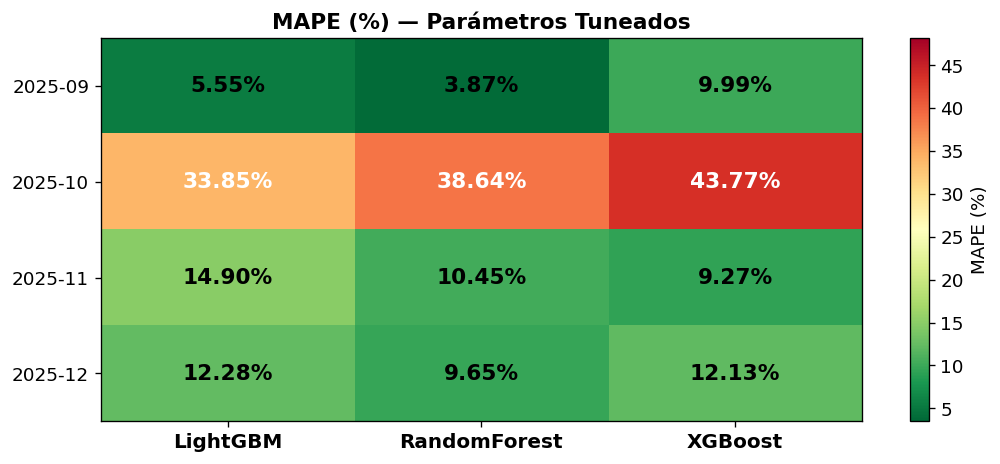

In [ ]:
mape_pivot = df_tun['MAPE (%)'].unstack('Modelo')

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(mape_pivot.values, cmap='RdYlGn_r', aspect='auto',
               vmin=mape_pivot.values.min()*0.9,
               vmax=mape_pivot.values.max()*1.1)

ax.set_xticks(range(len(mape_pivot.columns)))
ax.set_yticks(range(len(mape_pivot.index)))
ax.set_xticklabels(mape_pivot.columns, fontsize=12, fontweight='bold')
ax.set_yticklabels(mape_pivot.index, fontsize=11)
mean_val = mape_pivot.values.mean()
for i in range(len(mape_pivot.index)):
    for j in range(len(mape_pivot.columns)):
        v = mape_pivot.values[i,j]
        ax.text(j, i, f'{v:.2f}%', ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='white' if v > mean_val else 'black')
plt.colorbar(im, ax=ax, label='MAPE (%)')
ax.set_title('MAPE (%) — Parámetros Tuneados', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_mape_tuned.png', dpi=150, bbox_inches='tight')
plt.show()


## 16. Feature importance — LightGBM tuneado

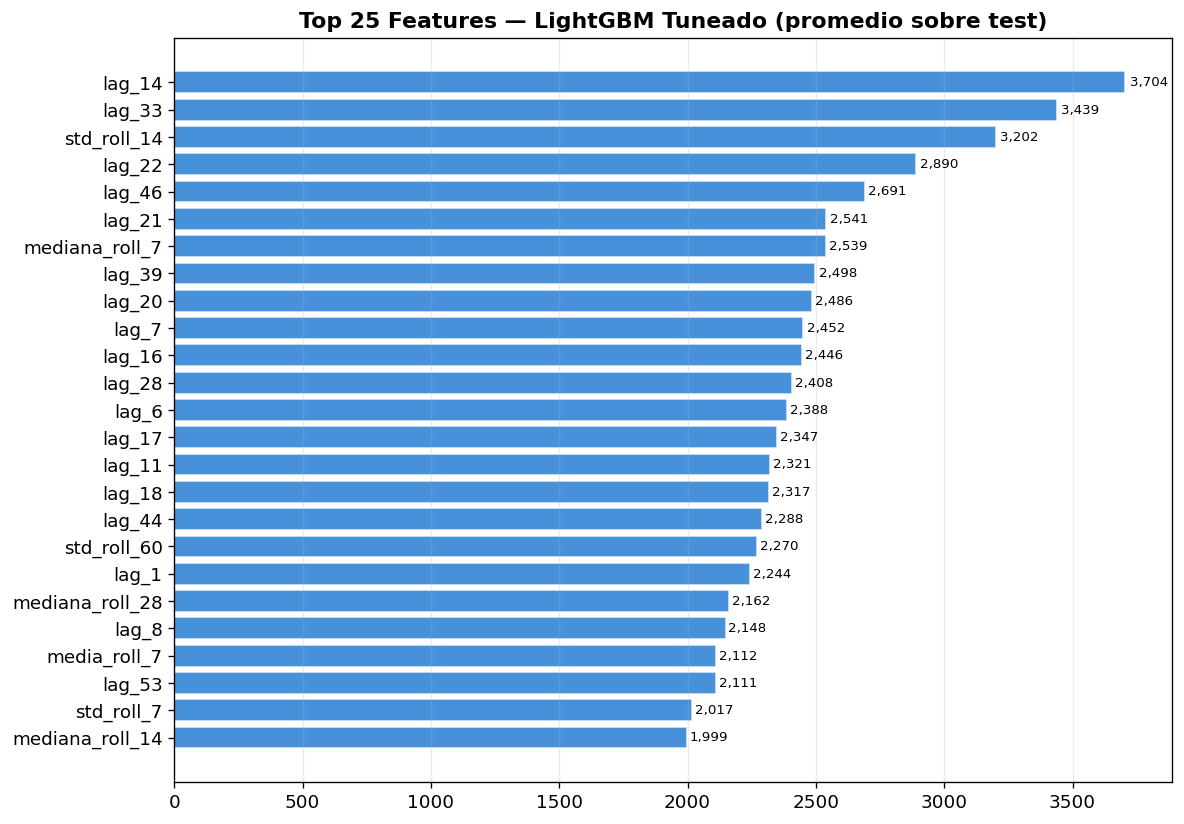

In [ ]:
if 'LightGBM' in MODELS:
    imps = [pd.Series(results_tuned[mes]['LightGBM']['model'].feature_importances_,
                      index=FEATURES_TREE)
            for mes in TEST_MONTHS]
    avg_imp = pd.concat(imps, axis=1).mean(axis=1).nlargest(25).sort_values()

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(avg_imp.index, avg_imp.values,
                   color='#1976D2', alpha=0.8, edgecolor='white')
    for bar,v in zip(bars, avg_imp.values):
        ax.text(v*1.005, bar.get_y()+bar.get_height()/2,
                f'{v:,.0f}', va='center', fontsize=8)
    ax.set_title('Top 25 Features — LightGBM Tuneado (promedio sobre test)',
                 fontweight='bold'); ax.grid(True, axis='x', alpha=0.25)
    plt.tight_layout()
    plt.savefig('feature_importance_tuned.png', dpi=150, bbox_inches='tight')
    plt.show()


## 17. APE promedio por horizonte — todos los meses de test

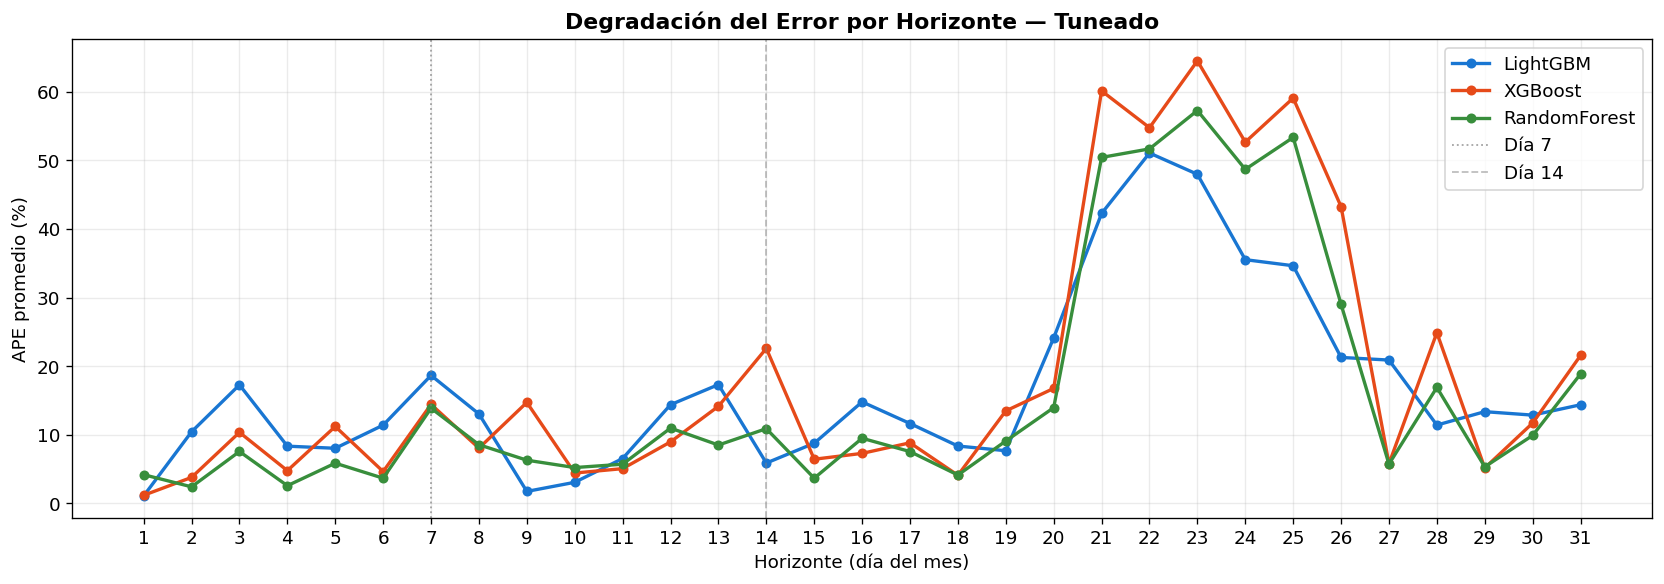

In [ ]:
records = []
for mes in TEST_MONTHS:
    real = results_tuned[mes][MODELS[0]]['real']
    for model_name in MODELS:
        preds = results_tuned[mes][model_name]['preds']
        for i,(e,rv) in enumerate(zip(np.abs(real-preds), real)):
            records.append({'Horizonte':i+1,'Modelo':model_name,
                            'APE': e/rv*100 if rv!=0 else np.nan})

ape_df    = pd.DataFrame(records)
ape_pivot = ape_df.groupby(['Horizonte','Modelo'])['APE'].mean().unstack('Modelo')

fig, ax = plt.subplots(figsize=(14, 5))
for model_name in MODELS:
    if model_name in ape_pivot.columns:
        ax.plot(ape_pivot.index, ape_pivot[model_name],
                '-o', ms=5, lw=2, color=COLORS[model_name], label=model_name)
ax.axvline(7,  color='gray', lw=1.1, ls=':',  alpha=0.7, label='Día 7')
ax.axvline(14, color='gray', lw=1.1, ls='--', alpha=0.5, label='Día 14')
ax.set_xlabel('Horizonte (día del mes)'); ax.set_ylabel('APE promedio (%)')
ax.set_title('Degradación del Error por Horizonte — Tuneado',
             fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.25)
ax.set_xticks(ape_pivot.index)
plt.tight_layout()
plt.savefig('ape_horizonte_tuned.png', dpi=150, bbox_inches='tight')
plt.show()


## 18. Exportar resultados

In [ ]:
all_rows = []
for mes in TEST_MONTHS:
    for model_name in MODELS:
        for tag, res in [('default', results_default),
                         ('tuned',   results_tuned)]:
            r = res[mes][model_name]
            for date, pred, real_v in zip(r['dates'], r['preds'], r['real']):
                all_rows.append({
                    'Fecha'     : date.date(),
                    'Mes'       : mes,
                    'Modelo'    : model_name,
                    'Variante'  : tag,
                    'Real'      : real_v,
                    'Prediccion': round(pred, 2),
                    'AbsError'  : round(abs(real_v - pred), 2),
                    'APE (%)'   : round(abs(real_v-pred)/real_v*100,4)
                                  if real_v != 0 else None,
                })

preds_df = pd.DataFrame(all_rows)
preds_df.to_csv('predicciones_tuned.csv', index=False)

# Tabla métricas combinada
df_def_exp = df_def.copy(); df_def_exp['variante'] = 'default'
df_tun_exp = df_tun.copy(); df_tun_exp['variante'] = 'tuned'
metrics_full = pd.concat([df_def_exp, df_tun_exp]).reset_index()
metrics_full.to_csv('metricas_tuned.csv', index=False)

# Mejores params
import json
with open('best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2, default=str)

print("Archivos exportados:")
print("  predicciones_tuned.csv   — predicciones día a día (default + tuned)")
print("  metricas_tuned.csv       — MAE/RMSE/MAPE/R² para ambas variantes")
print("  best_params.json         — mejores hiperparámetros encontrados")
print(f"\n{preds_df.head(8).to_string(index=False)}")


In [ ]:
import holidays
col = holidays.Colombia(years=2025)
for date, name in sorted(col.items()):
    print(date, name)

2025-01-01 New Year's Day
2025-01-06 Epiphany
2025-03-24 Saint Joseph's Day (observed)
2025-04-17 Maundy Thursday
2025-04-18 Good Friday
2025-05-01 Labor Day
2025-06-02 Ascension Day (observed)
2025-06-23 Corpus Christi (observed)
2025-06-30 Sacred Heart (observed); Saint Peter and Saint Paul's Day (observed)
2025-07-20 Independence Day
2025-08-07 Battle of Boyacá
2025-08-18 Assumption Day (observed)
2025-10-13 Columbus Day (observed)
2025-11-03 All Saints' Day (observed)
2025-11-17 Independence of Cartagena (observed)
2025-12-08 Immaculate Conception
2025-12-25 Christmas Day
